# Terzaghi Single-Layer Verification Notebook

This notebook investigates the generalised analytical solver for one dimensional Terzaghi consolidation between an arbitrary initial excess pore-pressure profile & a uniform initial excess pore-pressure profile.

1. To confirm that the formulation reproduces the classical Terzaghi solution when u0 is uniform; and  
2. (N)-convergence study, to assess convergence of the truncated Fourier-series solution for a non-uniform Boussinesq-based initial condition.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.analytical import Get_terzaghi1d_Analytical
from src.geotech_consolidation.models.terzaghi_1d.u0_analytical import Get_terzaghi1d_Analytical_u0

def boussinesq(z, load, base):
    z_min = np.maximum(z, 1e-12)
    term1 = np.arctan(base / (2.0 * z_min)) - np.arctan(-base / (2.0 * z_min))
    term2 = z_min * (((base) / ((base) ** 2 + z_min**2)) - ((-base) / ((-base) ** 2 + z_min**2)))
    return (load / np.pi) * (term1 + term2)

def error_metrics(reference, candidate): 
    diff = reference - candidate
    rmse = np.sqrt(np.mean(diff**2))
    max_err = np.max(np.abs(diff))
    norm_l2 = np.sqrt(np.sum(diff**2) / (np.sum(reference**2) + 1e-12))
    return {'rmse': rmse, 'max_abs': max_err, 'norm_l2': norm_l2}

H = 5.0
num = 100
nodes = num + 1
load = 100.0
Cv = 2e-7
time_steps = 1000
T = 365 * 24 * 60 * 60
time = np.linspace(0, T / (60 * 60 * 24), time_steps)
depth = np.linspace(0, H, nodes)

sns.set(style='whitegrid')


## Recovery Test: Uniform Initial Condition

This section checks that the generalized solver recovers the classical Terzaghi analytical solution when the initial excess pore pressure is prescribed as a constant with depth.

The comparison shown below contrasts:
- the classical uniform-initial-condition Fourier-series solution; and
- the generalized arbitrary-\(u_0\) solution evaluated using the same uniform profile.

Agreement between the two confirms that the generalized formulation is consistent with the standard closed-form solution in the special case of a uniform initial condition.

Minor oscillations near the drained surface are expected. These arise from **Gibbs phenomenon**, caused by the discontinuity between the prescribed initial excess pore pressure within the soil and the zero excess pore-pressure drainage boundary at the surface.


Uniform recovery metrics: {'rmse': np.float64(0.056395490948306114), 'max_abs': np.float64(13.18536240394603), 'norm_l2': np.float64(0.0008204000449288094)}


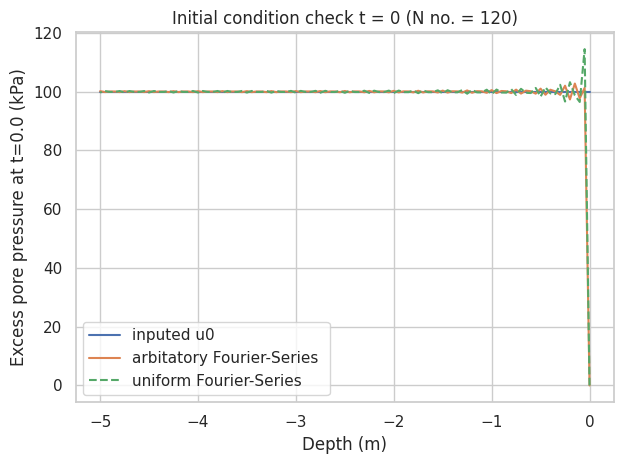

Sup (u0): 102.76218041874412, Inf: 97.34794708559045
Sup (uniform_u0): 114.47480729692798, Inf: 96.49118682006605


In [ ]:
uniform_u0 = np.ones(nodes) * load
N_terms_uniform = 120

cdata_std, u_std, depth_std, time_std = Get_terzaghi1d_Analytical(H, num, load, T, time_steps, Cv, N_terms_uniform)

u_u0, _, _ = Get_terzaghi1d_Analytical_u0(uniform_u0, H, num, T, time_steps, Cv, N_terms_uniform)
cdata_u0 = 1 - u_u0 / u_u0[0]

 
plt.figure()
plt.plot(-depth, uniform_u0, label='inputed u0')
plt.plot(-depth,u_u0[0], label='arbitatory Fourier-Series ')
plt.plot(-depth_std, u_std[0], '--', label='Uniform Fourier-Series')
plt.xlabel('Depth (m)')
plt.ylabel(f'Excess pore pressure at t={time_std[0]} (kPa)')
plt.legend()
plt.title(f'Initial condition check t = 0 (N no. = {N_terms_uniform})')
plt.tight_layout()
plt.show()

print(f'Sup (u0): {np.max(u_u0[0])}, Inf: {min(u for u in u_u0[0] if u != 0 )}')
print(f'Sup (uniform_u0): {np.max(u_std[0])}, Inf: {min(u for u in u_std[0] if u != 0 )}')

## \(N\)-Convergence Study: Boussinesq Initial Condition, \(u_0(z)\)

This section examines the behaviour of the Fourier-series solution when the initial excess pore-pressure distribution is non-uniform and derived from a Boussinesq-based stress profile.

First, the prescribed Boussinesq initial condition \(u_0(z)\) is compared against its Fourier-series reconstruction. This highlights the extent to which the truncated series represents the target initial profile, particularly near the surface where boundary incompatibility may again introduce local oscillation.

The consolidation solution is then evaluated for increasing Fourier truncation counts, \(N\), in order to assess convergence. Each truncated solution is compared against the finest retained case, which is taken as the reference solution. This provides a practical measure of series convergence with respect to the number of retained Fourier terms.

Where relevant, the effect of depth discretisation on reconstruction of the Boussinesq initial condition is also illustrated.

             rmse     max_abs   norm_l2
n_terms                                
20       0.245980   62.573664  0.005798
40       0.121195   31.012516  0.002857
80       0.036809    5.522743  0.000868
120      0.000000    0.000000  0.000000
200      2.171367  100.163127  0.051180


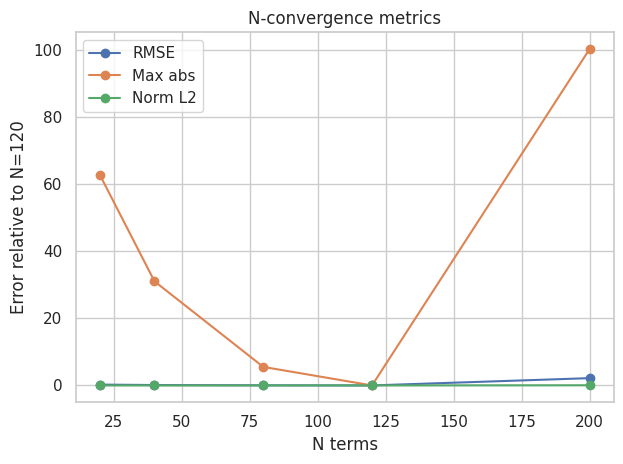

In [ ]:
boussinesq_u0 = boussinesq(depth, load, base=3.0)
n_values = [20, 40, 80, 120, 200]
results, solutions = [], {}

for n in sorted(n_values):
    u_data, _, _ = Get_terzaghi1d_Analytical_u0(boussinesq_u0, H, num, T, time_steps, Cv, n)
    solutions[n] = u_data
reference = solutions[120]

for n in sorted(n_values):
    metrics = error_metrics(reference, solutions[n])
    metrics['n_terms'] = n
    results.append(metrics)

df_conv = pd.DataFrame(results).set_index('n_terms')
print(df_conv)

plt.figure()
plt.plot(df_conv.index, df_conv['rmse'], marker='o', label='RMSE')
plt.plot(df_conv.index, df_conv['max_abs'], marker='o', label='Max abs')
plt.plot(df_conv.index, df_conv['norm_l2'], marker='o', label='Norm L2')
plt.xlabel('N terms')
plt.ylabel('Error relative to N=120')
plt.legend()
plt.title('N-convergence metrics')
plt.tight_layout()
plt.show()

